In [1]:
#importing the necessary dependencies
import numpy as np #for data analysis
import pandas as pd #for data analysis

import matplotlib.pyplot as plt #for data visualization
import seaborn as sns #for data visualization

In [2]:
#read the dataset using Pandas
data=pd.read_csv("/content/LoanApprovalPrediction+.csv")

In [3]:
data.head() #bydefault the .head() will show the first 5 records of the dataset

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
data.info() #.info() gives us the basic information about the entire dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            598 non-null    object 
 1   Gender             598 non-null    object 
 2   Married            598 non-null    object 
 3   Dependents         586 non-null    float64
 4   Education          598 non-null    object 
 5   Self_Employed      598 non-null    object 
 6   ApplicantIncome    598 non-null    int64  
 7   CoapplicantIncome  598 non-null    float64
 8   LoanAmount         577 non-null    float64
 9   Loan_Amount_Term   584 non-null    float64
 10  Credit_History     549 non-null    float64
 11  Property_Area      598 non-null    object 
 12  Loan_Status        598 non-null    object 
dtypes: float64(5), int64(1), object(7)
memory usage: 60.9+ KB


In [6]:
#checking for null or missing values in the dataset
data.isna().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,12
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,21
Loan_Amount_Term,14


In [26]:
#Since there are missing values in few of the columns, we will try to impute those missing values with the mean of the concerned column
data['Dependents'].fillna(data['Dependents'].mean(),inplace=True)
data['LoanAmount'].fillna(data['LoanAmount'].mean(),inplace=True)
data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].mean(),inplace=True)
data['Credit_History'].fillna(data['Credit_History'].mean(),inplace=True)

/tmp/ipykernel_1193/1155324693.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Dependents'].fillna(data['Dependents'].mean(),inplace=True)
/tmp/ipykernel_1193/1155324693.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inp

In [27]:
data.isna().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [7]:
#fleshing out the categorical columns and creating visualizations
obj=(data.dtypes=='object')
object_cols=list(obj[obj].index.values)
print(object_cols)

['Loan_ID', 'Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']


In [8]:
data['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [9]:
data['Gender'].value_counts()

,count
Gender,
Male,487
Female,111


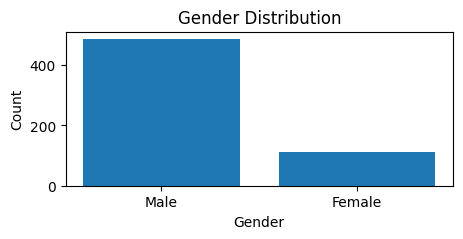

In [13]:
plt.figure(figsize=(5,2))
plt.bar(data['Gender'].unique(),data['Gender'].value_counts())
plt.xlabel('Gender') #x axis
plt.ylabel('Count') #y axis
plt.title('Gender Distribution') #name of the graph
plt.show()

In [14]:
data['Loan_Status'].value_counts()

,count
Loan_Status,
Y,411
N,187


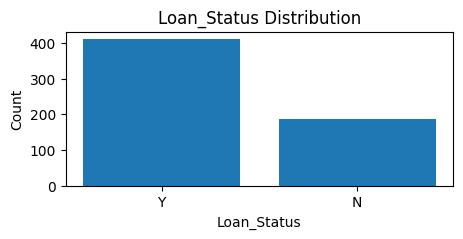

In [15]:
plt.figure(figsize=(5,2))
plt.bar(data['Loan_Status'].unique(),data['Loan_Status'].value_counts())
plt.xlabel('Loan_Status') #x axis
plt.ylabel('Count') #y axis
plt.title('Loan_Status Distribution') #name of the graph
plt.show()

Since the ML Models do not understand categorical data, it becomes necessaary for us to convert the categorical columns into numeric

- One Hot Encoding
- Label Encoding

In [16]:
#using Label Encoding we will convert the categorical columns into numeric
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [17]:
#Gender
data['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [19]:
data['Gender']=le.fit_transform(data['Gender'])

In [20]:
data['Gender'].unique()

array([1, 0])

In [21]:
#Self Employed
data['Self_Employed'].unique()

array(['No', 'Yes'], dtype=object)

In [24]:
data['Self_Employed']=le.fit_transform(data['Self_Employed'])

In [25]:
data['Self_Employed'].unique()

array([0, 1])